In [909]:
from utils import process_remote
from preparation import slice_by_dates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression, RANSACRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

In [910]:
terra_df1 = process_remote(
    filepath='../data/processed/satellites/SDH1_MT_500m_2000-03_2026-06.csv',
    duplicates=True, reindex=True,
    outliers=True, z_thresh=3, ignore_vars=['sensor_zenith', 'solar_zenith'],
    stats=False,
    filter_cols=False,
    interpolation=True, strategy='time',
    smooth=True, window_length= 25, polyorder=2 # ventana de 25 dias maximiza r2 test en 4/6 bandas
)
landsat_df1 = process_remote(
    filepath='../data/processed/satellites/SDH1_L_30m_1984-07_2026-06.csv',
    duplicates=True, reindex=True,
    outliers=True, z_thresh=2,
    stats=True,
    filter_cols=True,
    remote_cols=['blue_mean', 'green_mean', 'red_mean', 'nir_mean', 'swir1_mean', 'swir2_mean'],
    interpolation=False,
    smooth=False
)

In [911]:
terra_df1 = slice_by_dates(terra_df1, '2000', '2026')
landsat_df1 = slice_by_dates(landsat_df1, '2000', '2026')

In [912]:
# def filter_by_percentiles(df, pLow, pHigh):

#     # First, filter values outside valid reflectance range (0-1)
#     df_filtered_1 = df.where((df>=0) & (df<=1))

#     # Set percentile thresholds
#     pLow = df_filtered_1.quantile(pLow)
#     pHigh = df_filtered_1.quantile(pHigh)

#     # Second, filter values outside percentile thresholds
#     df_filtered_2 = df_filtered_1.where((df_filtered_1>=pLow) & (df_filtered_1<=pHigh))

#     return df_filtered_1

# landsat_df1_filtered = filter_by_percentiles(landsat_df1, 0.025, 0.975)
# terra_df1_filtered = filter_by_percentiles(terra_df1, 0, 1)

In [913]:
# Format -> 'Final Output Name': ('Landsat_Column_Name', 'MODIS_Column_Name')
band_mapping = {
    'blue':  ('blue_mean',  'blue'),
    'green': ('green_mean', 'green'),
    'red':   ('red_mean',   'red'),
    'nir':   ('nir_mean',   'nir'),
    'swir1': ('swir1_mean', 'swir1'),
    'swir2': ('swir2_mean', 'swir2')
}

In [914]:
def get_coincident_data(s_landsat, s_modis):
    """
    Aligns Landsat and MODIS series by their DatetimeIndex 
    and extracts coincident valid observations.
    """
    df_aligned = pd.concat([s_landsat, s_modis], axis=1, keys=['landsat', 'modis'])
    df_coincident = df_aligned.dropna()
    return df_coincident


def train_sensor_model(df_coincident, test_size=0.3, random_state=42):
    """
    Splits the coincident data into training and testing sets, 
    prints an OLS summary and trains a linear regression model.
    """
    X = df_coincident[['modis']].values
    y = df_coincident['landsat'].values
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    # Train the Linear Regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Create and print a summary using statsmodels
    X_train_sm = sm.add_constant(X_train)
    ols_model = sm.OLS(y_train, X_train_sm).fit()
    print(ols_model.summary())

    return model, X_train, X_test, y_train, y_test

# def train_sensor_model(df_coincident, test_size=0.3, min_samples=0.1, random_state=42):
#     """
#     Splits the coincident data into training and testing sets, trains
#     a robust RANSAC linear regression model and prints an OLS summary.
#     """
#     X = df_coincident[['modis']].values
#     y = df_coincident['landsat'].values
    
#     # Split the data
#     X_train, X_test, y_train, y_test = train_test_split(
#         X, y, test_size=test_size, random_state=random_state
#     )
    
#     # Train the Linear Regression model with RANSAC
#     base_estimator = LinearRegression()
#     model = RANSACRegressor(estimator=base_estimator, min_samples=min_samples, random_state=random_state)
#     model.fit(X_train, y_train)

#     # Create an inlier mask and filter the X and y training sets
#     inlier_mask = model.inlier_mask_
#     X_train_inlier = X_train[inlier_mask]
#     y_train_inlier = y_train[inlier_mask]

#     # Create and print a summary of the inlier data using statsmodels
#     X_train_sm = sm.add_constant(X_train_inlier)
#     ols_model = sm.OLS(y_train_inlier, X_train_sm).fit()
#     print(ols_model.summary())

#     return model, X_train_inlier, X_test, y_train_inlier, y_test


def plot_sensor_relationship(X_train, y_train, band_name):
    """
    Plots MODIS vs Landsat training data, including the trend line 
    and the line equation.
    """
    x_flat = X_train.flatten()
    
    # Calculate linear fit parameters (m = slope, b = intercept)
    m, b = np.polyfit(x_flat, y_train, 1)
    # Print equation to console
    print(f"Equation : y = {m:.4f}x + {b:.4f}")

    # Calculate global minimum and maximum
    global_min = min(x_flat.min(), y_train.min()) - 0.02
    global_max = max(x_flat.max(), y_train.max()) + 0.02
    
    plt.figure(figsize=(6, 5))
    
    # Scatter plot of training data
    plt.scatter(x_flat, y_train, alpha=0.6, color='#2A9D8F', label='Train set', s=20)
    
    # Plot trend line
    line_x = np.array([x_flat.min(), x_flat.max()])
    line_y = m * line_x + b
    plt.plot(line_x, line_y, color='#E76F51', linewidth=2, label='Trend line')

    plt.xlim(global_min, global_max)
    plt.ylim(global_min, global_max)
    #plt.gca().set_aspect('equal', adjustable='box')
    
    plt.title(f'MODIS vs Landsat relationship - {band_name}')
    plt.xlabel('MODIS reflectance')
    plt.ylabel('Landsat reflectance')
    plt.legend()
    plt.grid(True, linestyle='-', alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_observed_vs_modeled(model, X_train, X_test, y_train, y_test, band_name):
    """
    Plots Observed vs modeled values, differentiating between train and test sets.
    Calculates and prints metrics for both sets.
    """
    # Generate predictions for both sets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics for Training set
    r2_tr = r2_score(y_train, y_train_pred)
    mae_tr = mean_absolute_error(y_train, y_train_pred)
    rmse_tr = np.sqrt(mean_squared_error(y_train, y_train_pred))
    
    # Calculate metrics for Testing set
    r2_te = r2_score(y_test, y_test_pred)
    mae_te = mean_absolute_error(y_test, y_test_pred)
    rmse_te = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # Print evaluations to console
    print(f"--- {band_name}: Model evaluation ---")
    print(f"Train - R2: {r2_tr:.2f} | MAE: {mae_tr:.4f} | RMSE: {rmse_tr:.4f}")
    print(f"Test  - R2: {r2_te:.2f} | MAE: {mae_te:.4f} | RMSE: {rmse_te:.4f}")
    
    plt.figure(figsize=(6, 5))
    
    # Plot training predictions
    plt.scatter(y_train, y_train_pred, alpha=0.6, color='#2A9D8F', label='Train set', s=20)
    
    # Plot testing predictions
    plt.scatter(y_test, y_test_pred, alpha=1, color='#E9C46A', label='Test set', s=30, marker='x')
    
    # Plot 1:1 reference line
    all_y = np.concatenate([y_train, y_test, y_train_pred, y_test_pred])
    min_val, max_val = all_y.min(), all_y.max()
    plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', lw=1, label='1:1 line')
    
    plt.title(f'Observed vs modeled reflectance - {band_name}')
    plt.xlabel('Observed (Landsat)')
    plt.ylabel('Modeled (from MODIS)')
    plt.legend()
    plt.grid(True, linestyle='-', alpha=0.2)
    plt.tight_layout()
    plt.show()


def anchor_predictions_with_residuals(s_landsat, s_predict_daily, daily_index):
    """
    Anchors daily predictions to real Landsat observations 
    and smoothly distributes residuals over time.
    """
    # Align original Landsat series to the continuous daily index
    s_landsat_daily = s_landsat.reindex(daily_index)
    
    # Calculate the residual (error) exclusively on days with real observations
    residuals = s_landsat_daily - s_predict_daily
    
    # Interpolate residuals over time for missing days
    residuals_interpolated = residuals.interpolate(method='time').bfill().ffill()
    
    # Anchor the prediction by adding the continuous error surface
    s_final_anchored = s_predict_daily + residuals_interpolated
    
    return s_final_anchored, residuals


def generate_daily_landsat_series(df_landsat, df_modis, band_mapping):
    """
    Main function to execute the daily time-series generation pipeline.
    """
    # Define the continuous daily timeline based on MODIS data extent
    start_date = df_modis.index.min()
    end_date = df_modis.index.max()
    daily_index = pd.date_range(start=start_date, end=end_date, freq='D')
    
    # Initialize the empty output DataFrame
    df_predicted_landsat = pd.DataFrame(index=daily_index)
    df_residuals = pd.DataFrame()
    df_residuals_int = pd.DataFrame()
    
    # Loop through each band defined in the mapping dictionary
    for output_band_name, (landsat_col, modis_col) in band_mapping.items():
        
        if landsat_col not in df_landsat.columns or modis_col not in df_modis.columns:
            print(f"Warning: Columns for {output_band_name} not found. Skipping.")
            continue
            
        s_landsat = df_landsat[landsat_col]
        s_modis = df_modis[modis_col]
        
        # Step 1: Extract coincident data
        df_coincident = get_coincident_data(s_landsat, s_modis)
        if df_coincident.empty:
            print(f"Warning: No valid coincident dates found for {output_band_name}. Skipping.")
            continue
            
        print(f"\n{'='*50}\nProcessing {output_band_name} ({len(df_coincident)} coincident points)\n{'='*50}")
        
        # Step 2: Train/test split and model training
        model, X_train, X_test, y_train, y_test = train_sensor_model(df_coincident)
        
        # Step 3: Plot MODIS vs Landsat relationship (Training data)
        plot_sensor_relationship(X_train, y_train, output_band_name)
        
        # Step 4: Plot Observed vs Modeled (Train and test data)
        plot_observed_vs_modeled(model, X_train, X_test, y_train, y_test, output_band_name)
        
        # Step 5: Prepare continuous MODIS predictor data
        s_modis_daily = s_modis.reindex(daily_index)
        s_modis_clean = s_modis_daily.interpolate(method='time').bfill().ffill()
        X_predict = s_modis_clean.values.reshape(-1, 1)
        
        # Step 6: Predict base daily values
        y_predict = model.predict(X_predict)
        s_predict_daily = pd.Series(y_predict, index=daily_index)
        
        # Step 7: Anchor predictions to observed values using residuals
        s_final_anchored, residuals = anchor_predictions_with_residuals(s_landsat, s_predict_daily, daily_index)
        
        # Store the final anchored series in the output DataFrame
        #df_predicted_landsat[output_band_name] = s_final_anchored
        df_predicted_landsat[output_band_name] = s_predict_daily    # no anchored alternative

        # Store the residuals in a df
        df_residuals[output_band_name] = residuals
        
    return df_predicted_landsat, df_residuals


Processing blue (701 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.741
Method:                 Least Squares   F-statistic:                     1402.
Date:                Sun, 26 Jul 2026   Prob (F-statistic):          1.34e-145
Time:                        18:12:34   Log-Likelihood:                 876.24
No. Observations:                 490   AIC:                            -1748.
Df Residuals:                     488   BIC:                            -1740.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

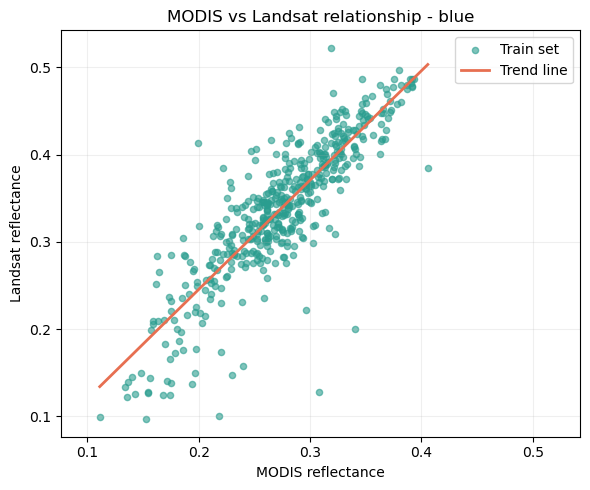

--- blue: Model evaluation ---
Train - R2: 0.74 | MAE: 0.0280 | RMSE: 0.0405
Test  - R2: 0.71 | MAE: 0.0305 | RMSE: 0.0435


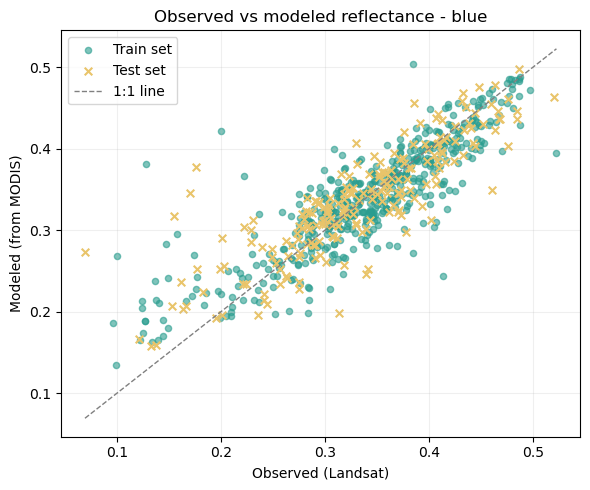


Processing green (724 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     1439.
Date:                Sun, 26 Jul 2026   Prob (F-statistic):          8.70e-150
Time:                        18:12:34   Log-Likelihood:                 868.11
No. Observations:                 506   AIC:                            -1732.
Df Residuals:                     504   BIC:                            -1724.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     

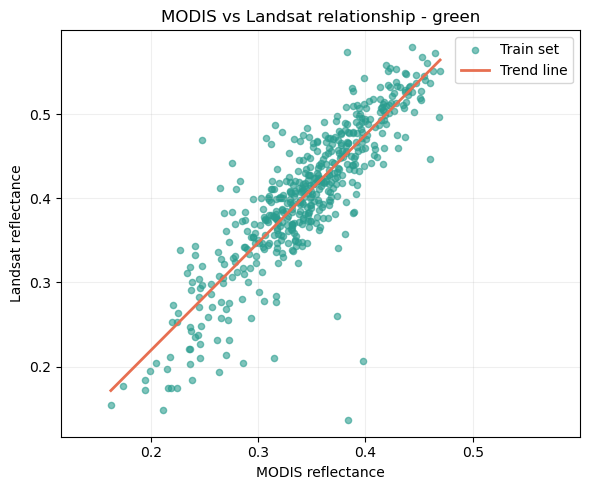

--- green: Model evaluation ---
Train - R2: 0.74 | MAE: 0.0302 | RMSE: 0.0435
Test  - R2: 0.70 | MAE: 0.0310 | RMSE: 0.0464


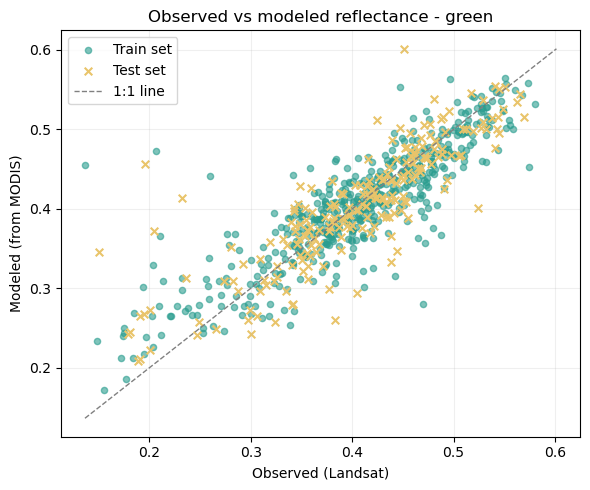


Processing red (699 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.722
Model:                            OLS   Adj. R-squared:                  0.721
Method:                 Least Squares   F-statistic:                     1262.
Date:                Sun, 26 Jul 2026   Prob (F-statistic):          2.66e-137
Time:                        18:12:34   Log-Likelihood:                 776.05
No. Observations:                 489   AIC:                            -1548.
Df Residuals:                     487   BIC:                            -1540.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

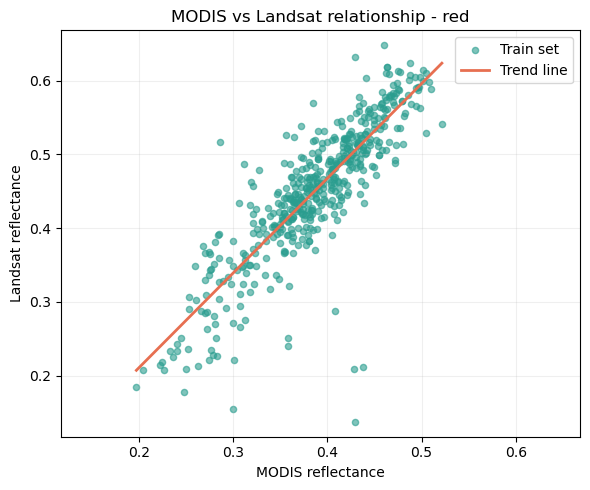

--- red: Model evaluation ---
Train - R2: 0.72 | MAE: 0.0329 | RMSE: 0.0495
Test  - R2: 0.67 | MAE: 0.0317 | RMSE: 0.0452


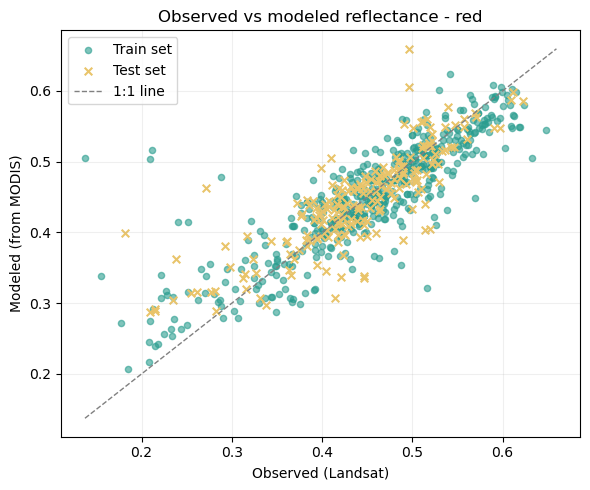


Processing nir (714 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.724
Method:                 Least Squares   F-statistic:                     1309.
Date:                Sun, 26 Jul 2026   Prob (F-statistic):          2.26e-141
Time:                        18:12:34   Log-Likelihood:                 886.47
No. Observations:                 499   AIC:                            -1769.
Df Residuals:                     497   BIC:                            -1761.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

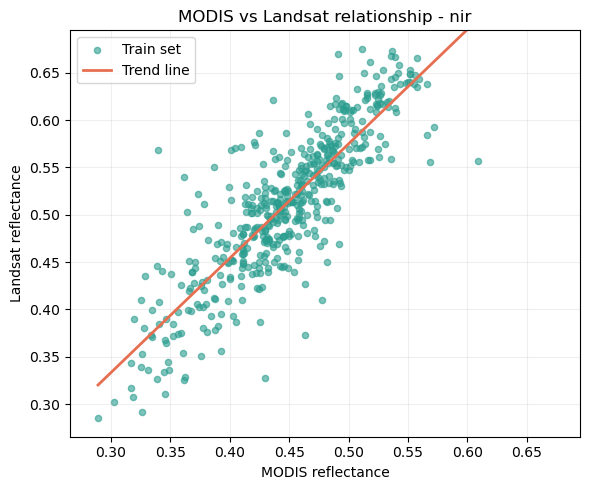

--- nir: Model evaluation ---
Train - R2: 0.72 | MAE: 0.0301 | RMSE: 0.0409
Test  - R2: 0.72 | MAE: 0.0319 | RMSE: 0.0427


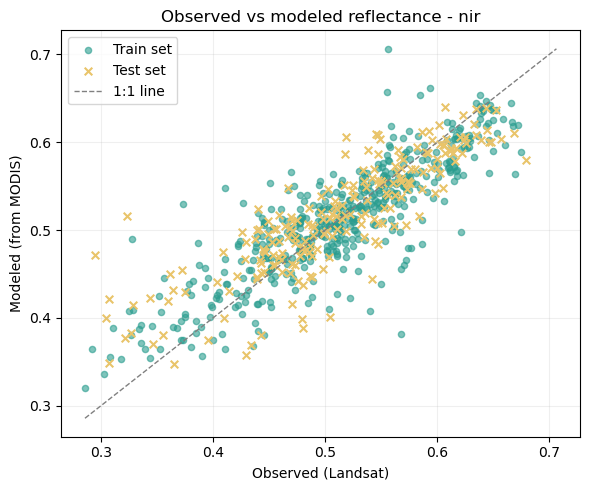


Processing swir1 (731 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.801
Model:                            OLS   Adj. R-squared:                  0.801
Method:                 Least Squares   F-statistic:                     2053.
Date:                Sun, 26 Jul 2026   Prob (F-statistic):          9.01e-181
Time:                        18:12:35   Log-Likelihood:                 872.04
No. Observations:                 511   AIC:                            -1740.
Df Residuals:                     509   BIC:                            -1732.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     

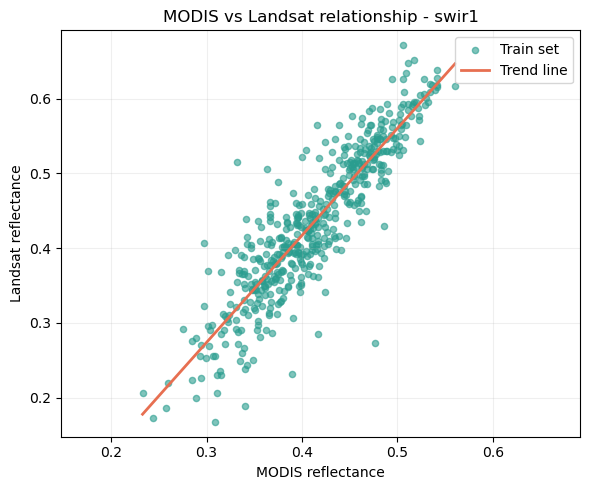

--- swir1: Model evaluation ---
Train - R2: 0.80 | MAE: 0.0317 | RMSE: 0.0439
Test  - R2: 0.77 | MAE: 0.0307 | RMSE: 0.0438


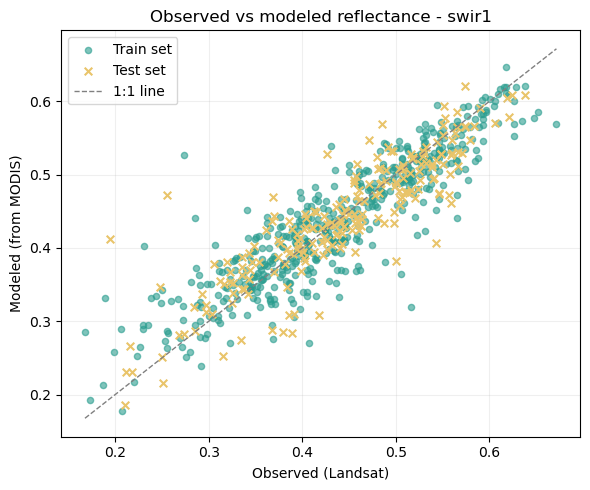


Processing swir2 (728 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     2454.
Date:                Sun, 26 Jul 2026   Prob (F-statistic):          1.94e-196
Time:                        18:12:35   Log-Likelihood:                 877.01
No. Observations:                 509   AIC:                            -1750.
Df Residuals:                     507   BIC:                            -1742.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     

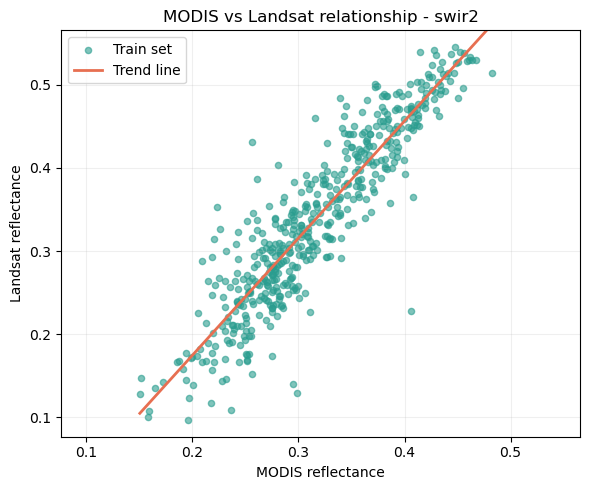

--- swir2: Model evaluation ---
Train - R2: 0.83 | MAE: 0.0318 | RMSE: 0.0432
Test  - R2: 0.80 | MAE: 0.0293 | RMSE: 0.0422


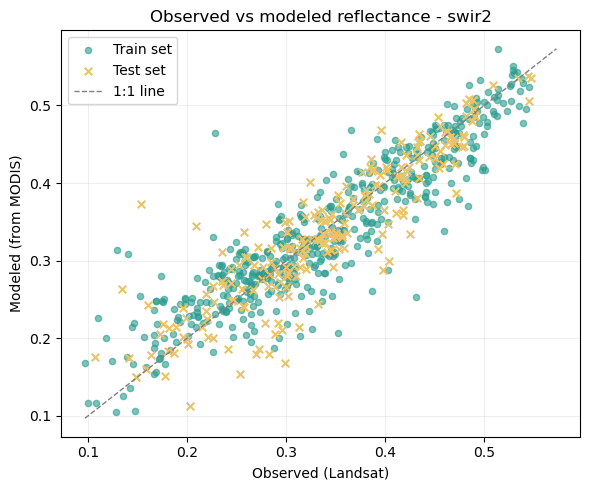

In [915]:
landsat_daily_df1, landsat_residuals_df1 = generate_daily_landsat_series(landsat_df1, terra_df1, band_mapping)

In [916]:
def plot_residuals_boxplot(df_residuals):
    """
    Generates a global violin plot of the residuals per band, overlaying 
    the individual data points.
    """
    # Transform the DataFrame to long format for Seaborn
    df_melted = df_residuals.melt(var_name='band', value_name='residual')
    df_melted = df_melted.dropna()

    plt.figure(figsize=(10, 6))

    # Plot the violin plot with a uniform color
    sns.violinplot(
        data=df_melted, 
        x='band', 
        y='residual', 
        color='#e0e0e0',
        alpha=0.3,
        inner=None, 
        linewidth=1
    )

    # Define the specific color palette for the bands
    band_palette = ['blue', 'green', 'red', 'purple', 'orange', 'saddlebrown']
    
    # Plot the individual points (Stripplot)
    sns.stripplot(
        data=df_melted, 
        x='band', 
        y='residual',
        hue='band',
        palette=band_palette,
        alpha=0.2,
        jitter=True,
        size=4,
        legend=False
    )
    
    plt.ylabel('Residual (reflectance)')
    plt.xlabel('')
    plt.grid(True, axis='y', linestyle='-', alpha=0.2)
    plt.tight_layout()
    plt.show()

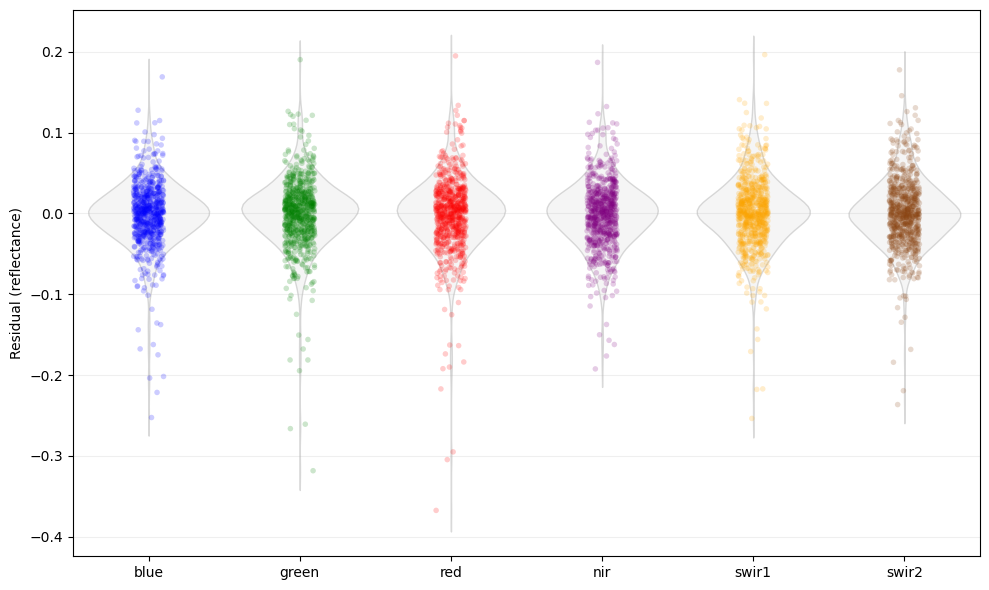

,blue,green,red,nir,swir1,swir2
2000-03-01,NaN,NaN,NaN,NaN,NaN,NaN
2000-03-02,NaN,NaN,NaN,NaN,NaN,NaN
2000-03-03,NaN,NaN,NaN,NaN,NaN,NaN
2000-03-04,NaN,NaN,NaN,NaN,NaN,NaN
2000-03-05,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2026-06-26,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-27,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-28,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-29,NaN,NaN,NaN,NaN,NaN,NaN


In [917]:
plot_residuals_boxplot(landsat_residuals_df1)
landsat_residuals_df1.describe()
landsat_residuals_df1

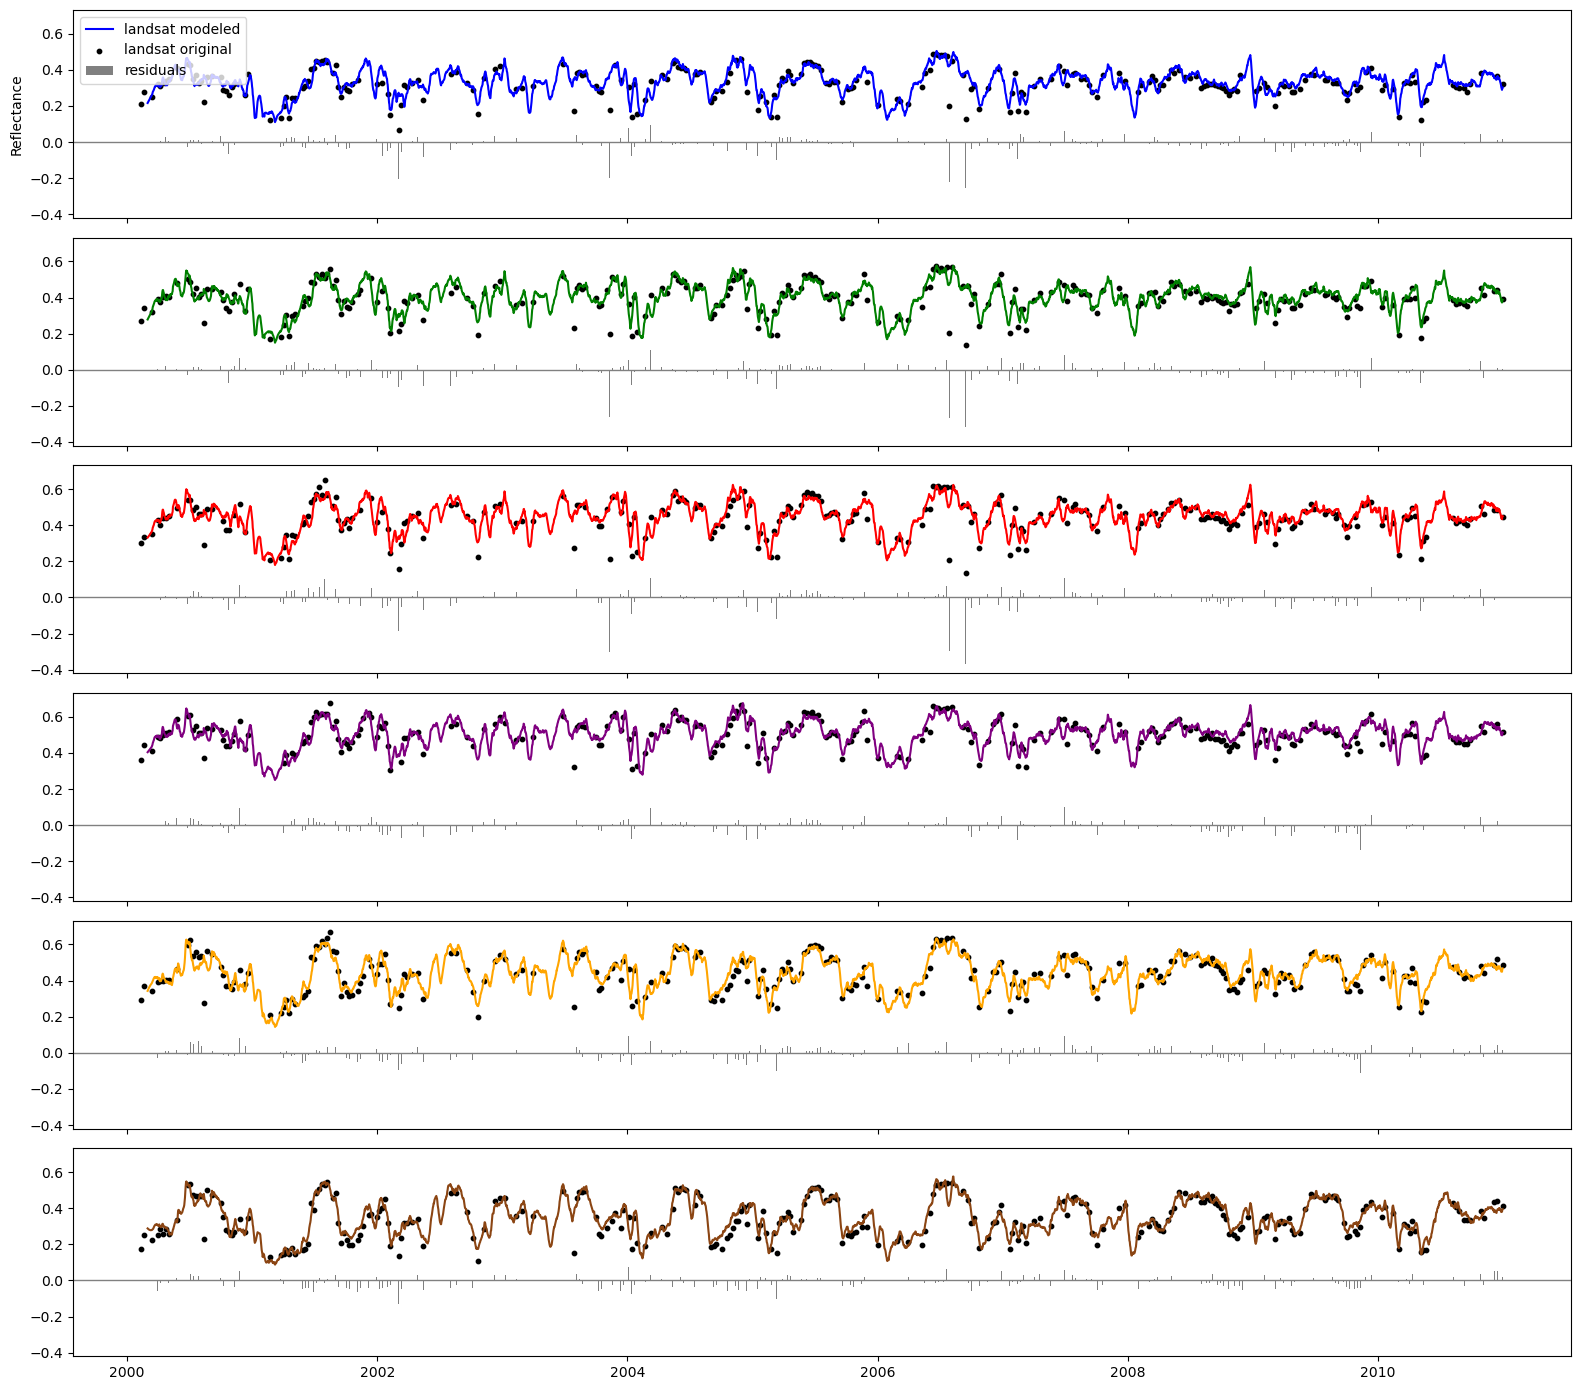

In [918]:
start = '2000'
end = '2010'

landsat_daily_df1 = slice_by_dates(landsat_daily_df1, start, end)
landsat_df1 = slice_by_dates(landsat_df1, start, end)
landsat_residuals_df1 = slice_by_dates(landsat_residuals_df1, start, end)

fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(6, 1, figsize=(16, 14), sharex=True, sharey=True)

ax1.plot(landsat_daily_df1.index, landsat_daily_df1['blue'], label='landsat modeled', c='blue')
ax1.scatter(landsat_df1.index, landsat_df1['blue_mean'], label='landsat original', color='black', s=10)
ax1.bar(landsat_residuals_df1.index, landsat_residuals_df1['blue'], label='residuals', color='gray', width=2)
ax1.set_ylabel('Reflectance')
ax1.legend(loc='upper left')
ax1.axhline(y=0, color='gray', linestyle='-', linewidth=1)

ax2.plot(landsat_daily_df1.index, landsat_daily_df1['green'], c='green')
ax2.scatter(landsat_df1.index, landsat_df1['green_mean'], color='black', s=10)
ax2.bar(landsat_residuals_df1.index, landsat_residuals_df1['green'], label='residuals', color='gray', width=2)
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=1)

ax3.plot(landsat_daily_df1.index, landsat_daily_df1['red'], c='red')
ax3.scatter(landsat_df1.index, landsat_df1['red_mean'], color='black', s=10)
ax3.bar(landsat_residuals_df1.index, landsat_residuals_df1['red'], label='residuals', color='gray', width=2)
ax3.axhline(y=0, color='gray', linestyle='-', linewidth=1)

ax4.plot(landsat_daily_df1.index, landsat_daily_df1['nir'], c='purple')
ax4.scatter(landsat_df1.index, landsat_df1['nir_mean'], color='black', s=10)
ax4.bar(landsat_residuals_df1.index, landsat_residuals_df1['nir'], label='residuals', color='gray', width=2)
ax4.axhline(y=0, color='gray', linestyle='-', linewidth=1)

ax5.plot(landsat_daily_df1.index, landsat_daily_df1['swir1'], c='orange')
ax5.scatter(landsat_df1.index, landsat_df1['swir1_mean'], color='black', s=10)
ax5.bar(landsat_residuals_df1.index, landsat_residuals_df1['swir1'], label='residuals', color='gray', width=2)
ax5.axhline(y=0, color='gray', linestyle='-', linewidth=1)

ax6.plot(landsat_daily_df1.index, landsat_daily_df1['swir2'], c='saddlebrown')
ax6.scatter(landsat_df1.index, landsat_df1['swir2_mean'], color='black', s=10)
ax6.bar(landsat_residuals_df1.index, landsat_residuals_df1['swir2'], label='residuals', color='gray', width=2)
ax6.axhline(y=0, color='gray', linestyle='-', linewidth=1)

plt.tight_layout()
plt.show()

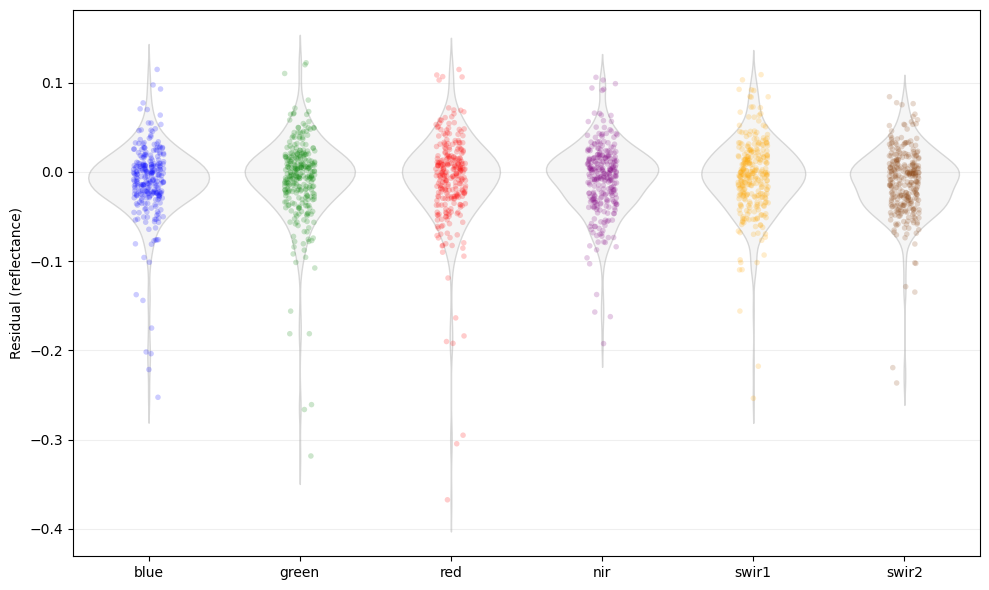

,blue,green,red,nir,swir1,swir2
count,265.000000,285.000000,273.000000,280.000000,290.000000,289.000000
mean,-0.010781,-0.008152,-0.009089,-0.007381,-0.005525,-0.011549
std,0.043463,0.048521,0.054442,0.040209,0.042843,0.038116
min,-0.252518,-0.318289,-0.367371,-0.192377,-0.253636,-0.236500
25%,-0.024965,-0.024961,-0.027714,-0.030264,-0.026741,-0.033772
50%,-0.007471,-0.003646,-0.001868,-0.003660,-0.003647,-0.008050
75%,0.009096,0.016503,0.016523,0.015625,0.017878,0.010689
max,0.114801,0.122218,0.114743,0.105956,0.108950,0.084216


In [919]:
plot_residuals_boxplot(landsat_residuals_df1)
landsat_residuals_df1.describe()